In [1]:
import sys
sys.path.append('..')
from src.preprocessing import load_data, clean_data, feature_engineering, split_data, save_processed_data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = load_data('../data/raw/ecommerce_customer_churn_dataset.csv')
df = clean_data(df)
print(df.shape)

(50000, 25)


In [3]:
X, y, X_raw = feature_engineering(df)
print(f"Признаков после обработки: {X.shape[1]}")

X_raw_aligned = X_raw.loc[y.index]

Признаков после обработки: 78


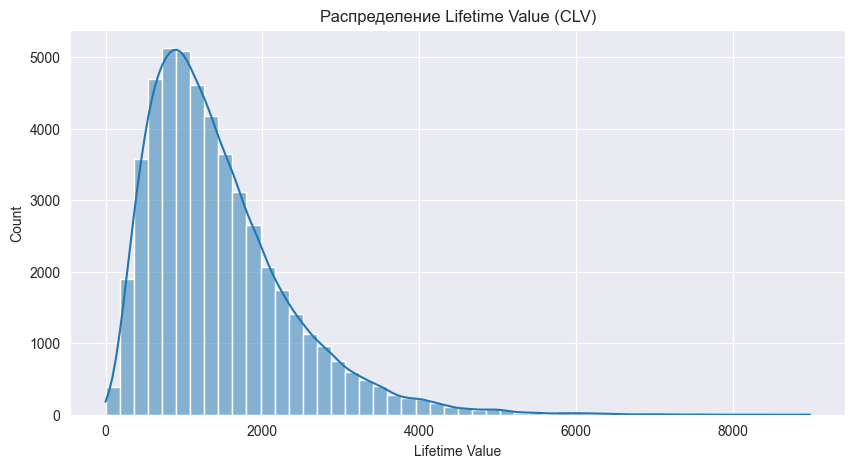


Интерпретация: Распределение Lifetime Value имеет длинный правый хвост 
(много клиентов с низким CLV и небольшое количество с очень высоким). 
Это типично для CLV-задач и означает, что метрика RMSE будет чувствительна 
к ошибкам на крупных клиентах, поэтому мы выбираем RMSE как основную метрику.



In [4]:
plt.figure(figsize=(10,5))
sns.histplot(y, bins=50, kde=True)
plt.title("Распределение Lifetime Value (CLV)")
plt.xlabel("Lifetime Value")
plt.show()
print("""
Интерпретация: Распределение Lifetime Value имеет длинный правый хвост 
(много клиентов с низким CLV и небольшое количество с очень высоким). 
Это типично для CLV-задач и означает, что метрика RMSE будет чувствительна 
к ошибкам на крупных клиентах, поэтому мы выбираем RMSE как основную метрику.
""")

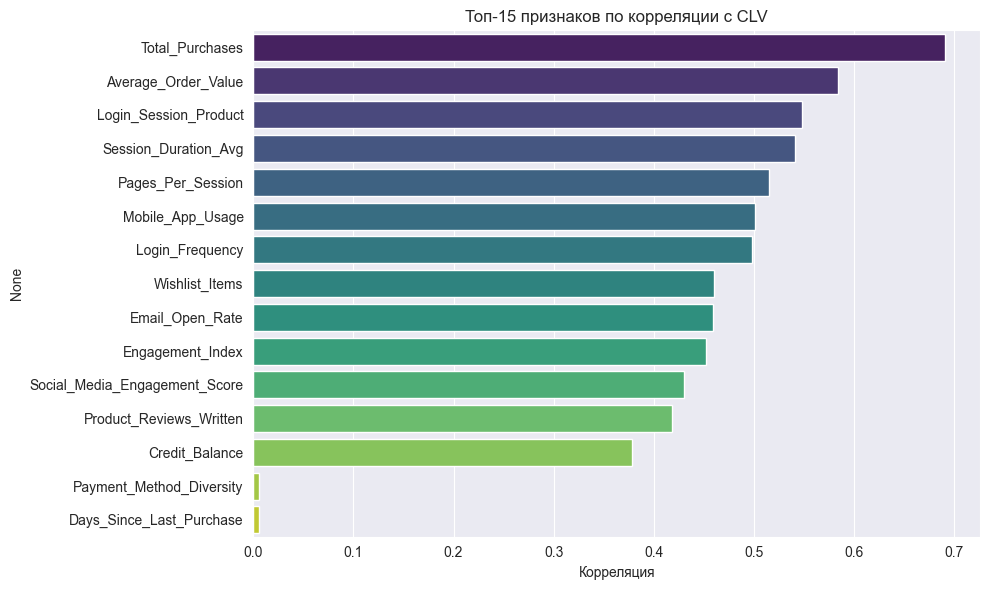


Интерпретация: Наибольшую положительную корреляцию с CLV имеют Total_Purchases,
Average_Order_Value, и созданные нами признаки (Login_Session_Product, Engagement_Index).
Это логично: клиенты, которые чаще покупают и тратят больше, приносят большую прибыль.



In [5]:
X_num = X.select_dtypes(include=[np.number])
corr_with_target = X_num.corrwith(y).sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index,
            hue=corr_with_target.index, palette='viridis', legend=False)
plt.title("Топ-15 признаков по корреляции с CLV")
plt.xlabel("Корреляция")
plt.tight_layout()
plt.show()
print("""
Интерпретация: Наибольшую положительную корреляцию с CLV имеют Total_Purchases,
Average_Order_Value, и созданные нами признаки (Login_Session_Product, Engagement_Index).
Это логично: клиенты, которые чаще покупают и тратят больше, приносят большую прибыль.
""")

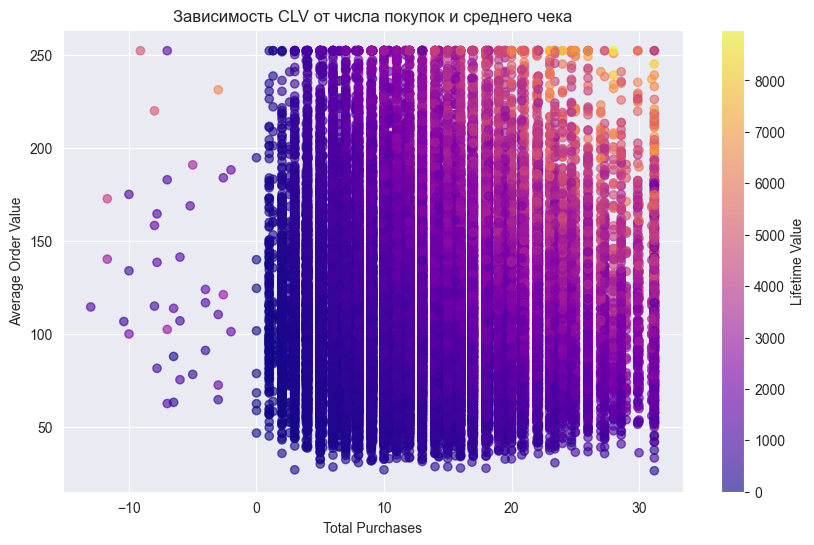


Интерпретация: Чем больше покупок и выше средний чек, тем выше CLV.
Видна положительная связь, но также присутствуют клиенты с высоким CLV при умеренных
покупках — возможно, за счёт других факторов (возраст, лояльность).



In [6]:
if 'Total_Purchases' in X.columns and 'Average_Order_Value' in X.columns:
    plt.figure(figsize=(10,6))
    sc = plt.scatter(X['Total_Purchases'], X['Average_Order_Value'], c=y, cmap='plasma', alpha=0.6)
    plt.colorbar(sc, label='Lifetime Value')
    plt.xlabel('Total Purchases')
    plt.ylabel('Average Order Value')
    plt.title("Зависимость CLV от числа покупок и среднего чека")
    plt.show()
    print("""
Интерпретация: Чем больше покупок и выше средний чек, тем выше CLV.
Видна положительная связь, но также присутствуют клиенты с высоким CLV при умеренных
покупках — возможно, за счёт других факторов (возраст, лояльность).
""")

In [7]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
print(f"Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")

Train (34997, 78), Val (7501, 78), Test (7500, 78)


In [8]:
save_processed_data(X, y, '../data/processed')
X_raw_encoded = pd.get_dummies(X_raw_aligned, drop_first=True)
X_raw_encoded.to_csv('../data/processed/X_raw_encoded.csv', index=False)

Сохранено в ../data/processed/
